In [1]:
%matplotlib inline



import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
import networkx as nx
from collections import defaultdict

mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['font.size'] = 20
mpl.rcParams['figure.autolayout'] = False
mpl.rcParams['axes.linewidth'] = 3
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['lines.linewidth'] = 2.2
mpl.rcParams['lines.markersize'] = 5
mpl.rcParams['lines.markeredgewidth'] = 1.2
mpl.rcParams['errorbar.capsize'] = 5
mpl.rcParams['xtick.major.width'] = 3
mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['ytick.major.width'] = 3
mpl.rcParams['ytick.major.size'] = 8
mpl.rcParams['xtick.minor.width'] = 1.5
mpl.rcParams['xtick.minor.size'] = 6
mpl.rcParams['ytick.minor.width'] = 1.5
mpl.rcParams['ytick.minor.size'] = 6
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['mathtext.fontset'] = 'dejavusans'
mpl.rcParams['font.family'] = 'sans-serif'
cm_colors = plt.get_cmap('Set2')


In [2]:
def plot_layout_background(layout, layers, ax, alpha=0.5):
    G = nx.Graph()
    G.add_nodes_from(layout.keys())
    G.add_edges_from(layers[0]+ layers[1] + layers[2])
    pos = [[i[1],-i[0]] for i in layout.values()]
    nx.draw_networkx_nodes(G, pos, ax=ax, edgecolors="black", node_color="grey", alpha=alpha)
    nx.draw_networkx_edges(G, pos, width=13, alpha=alpha, edge_color="grey", ax=ax)

def shortest_path(nq_chain, G_entropy):
    num_qubits = G_entropy.number_of_nodes()
    paths = []
    S_total = []
    for i in range(num_qubits):
        for j in range(i+1, num_qubits):
            sp = nx.shortest_path(G_entropy, source=i, target=j)
            if len(sp) == nq_chain:
                Sab = 0
                for k in range(nq_chain-1):
                    # if [sp[k],sp[k+1]] != [99,115]:
                    Sab += G_entropy[sp[k]][sp[k+1]]["weight"]
                paths.append(sp)
                S_total.append(Sab)
    return np.array(S_total), paths

layout_fez = {0:(0,0), 1:(0,1), 2:(0,2), 3:(0,3), 4:(0,4), 5:(0,5), 6:(0,6), 7:(0,7), 8:(0,8), 9:(0,9), 10:(0,10), 11:(0,11), 12:(0,12), 13:(0,13), 14:(0,14), 15:(0,15),
                16:(1,3), 17:(1,7), 18:(1,11),19:(1,15),
                20:(2,0), 21:(2,1), 22:(2,2), 23:(2,3), 24:(2,4), 25:(2,5), 26:(2,6), 27:(2,7), 28:(2,8), 29:(2,9), 30:(2,10), 31:(2,11), 32:(2,12), 33:(2,13), 34:(2,14), 35:(2,15),
                36:(3,1), 37:(3,5), 38:(3,9), 39:(3,13),
                40:(4,0), 41:(4,1), 42:(4,2), 43:(4,3), 44:(4,4), 45:(4,5), 46:(4,6), 47:(4,7), 48:(4,8), 49:(4,9), 50:(4,10), 51:(4,11), 52:(4,12), 53:(4,13), 54:(4,14), 55:(4,15),
                56:(5,3), 57:(5,7), 58:(5,11), 59:(5,15),
                60:(6,0), 61:(6,1), 62:(6,2), 63:(6,3), 64:(6,4), 65:(6,5), 66:(6,6), 67:(6,7), 68:(6,8), 69:(6,9), 70:(6,10), 71:(6,11), 72:(6,12), 73:(6,13), 74:(6,14), 75:(6,15),
                76:(7,1), 77:(7,5), 78:(7,9), 79:(7,13),
                80:(8,0), 81:(8,1), 82:(8,2), 83:(8,3), 84:(8,4), 85:(8,5), 86:(8,6), 87:(8,7), 88:(8,8), 89:(8,9), 90:(8,10), 91:(8,11), 92:(8,12), 93:(8,13), 94:(8,14), 95:(8,15),
                96:(9,3), 97:(9,7), 98:(9,11), 99:(9,15),
                100:(10,0), 101:(10,1), 102:(10,2), 103:(10,3), 104:(10,4), 105:(10,5), 106:(10,6), 107:(10,7), 108:(10,8), 109:(10,9), 110:(10,10), 111:(10,11), 112:(10,12), 113:(10,13), 114:(10,14), 115:(10,15),
                116:(11,1), 117:(11,5), 118:(11,9), 119:(11,13),
                120:(12,0), 121:(12,1), 122:(12,2), 123:(12,3), 124:(12,4), 125:(12,5), 126:(12,6), 127:(12,7), 128:(12,8), 129:(12,9), 130:(12,10), 131:(12,11), 132:(12,12), 133:(12,13), 134:(12,14), 135:(12,15),
                136:(13,3), 137:(13,7), 138:(13,11), 139:(13,15),
                140:(14,0), 141:(14,1), 142:(14,2), 143:(14,3), 144:(14,4), 145:(14,5), 146:(14,6), 147:(14,7), 148:(14,8), 149:(14,9), 150:(14,10), 151:(14,11), 152:(14,12), 153:(14,13), 154:(14,14), 155:(14,15),}

In [6]:
import numpy as np
import networkx as nx

nq = 156
backend_name = "ibm_fez"
layout = "HE"
data = np.load(f"./Data/{backend_name}/graph.npy", allow_pickle=True).item()
G = data["G"]
distance = np.zeros((nq, nq))
for node in range(nq):
    path_lengths = nx.single_source_shortest_path_length(G, node)
    for qj, dist in path_lengths.items():
        distance[node, qj] = dist

[88, 87, 97, 107, 106, 105, 117, 125, 124, 123, 136, 143, 142, 141, 140] 0.47574280313022166


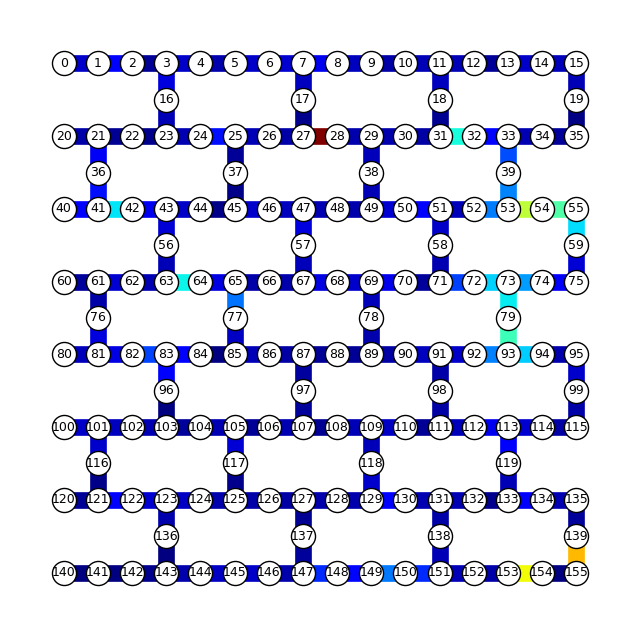

In [8]:
G = nx.Graph()
for layer in range(3):
    data = np.load(f"./Data/ibm_fez/shadows_{layer}.npy", allow_pickle=True).item()
    for nn, qubits in enumerate(data["entropy_systems"]):
        if len(qubits) == 2:
            G.add_weighted_edges_from([qubits+[np.mean(data["Sab"][nn])]])

np.save("./Data/ibm_fez/G_crosstalk.npy", {"G":G})
Sij, paths =  shortest_path(15, G)
print(paths[np.argmin(Sij)], np.min(Sij))
colors = plt.get_cmap("jet")
pos = [[i[1],-i[0]] for i in layout_fez.values()]
weights = np.array([G[i][j]["weight"] for i, j in G.edges])
norm_weights = (weights - weights.min())/(weights.max() - weights.min())
edge_colors = [colors(w) for w in norm_weights]

fig, ax = plt.subplots(figsize=(8,8))
nx.draw(G, pos=pos, ax=ax, font_size=9, edgecolors="black", width=12, edge_color=edge_colors, node_color="white",with_labels=True)
fig.savefig(f"./Figures/ibm_fez_crosstalk.pdf", bbox_inches="tight", transparent=True)


In [9]:
G_entropy = np.load("./Data/average_entropy_fez.npy", allow_pickle=True).item()["G"]
Sij, paths =  shortest_path(20, G_entropy)
print(paths[np.argmin(Sij)], np.min(Sij))

[71, 70, 69, 78, 89, 88, 87, 97, 107, 106, 105, 117, 125, 124, 123, 136, 143, 142, 141, 140] 2.7063797608959117


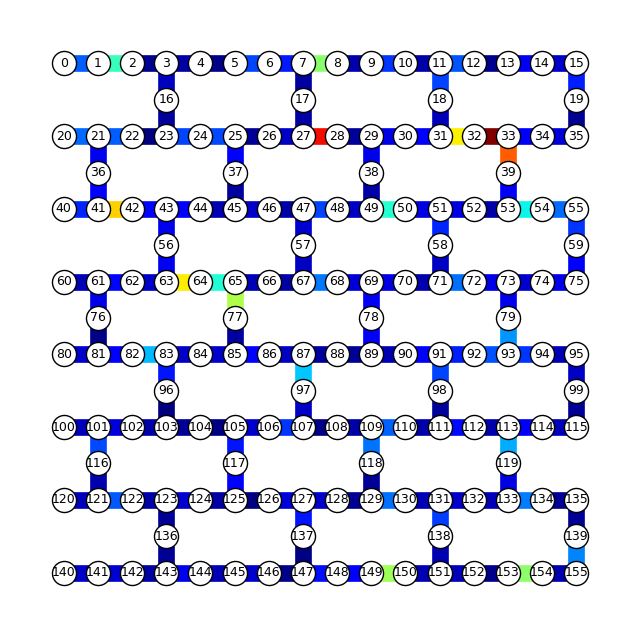

In [11]:
layers = [0,1,2]
prop_name = "D"
data = {layer: np.load(f"./Data/ibm_fez/shadows_{layer}.npy", allow_pickle=True).item() for layer in layers}
layer = data[0]["layers"]
pos = [[i[1],-i[0]] for i in layout_fez.values()]
colors = plt.get_cmap("jet")
G = nx.Graph()
G.add_nodes_from(range(127))

edges_weight = []
for nn, edges in enumerate(layer):
    for qubits in edges:
        prop = data[nn]["postprocessing"][tuple(qubits)]["ZECS"][prop_name][-1]
        G.add_weighted_edges_from([[qubits[0],qubits[1],prop]])

weights = np.array([G[i][j]["weight"] for i, j in G.edges])
norm_weights = (weights - weights.min())/(weights.max() - weights.min())
edge_colors = [colors(w) for w in norm_weights]

fig, ax = plt.subplots(figsize=(8,8))
nx.draw(G, pos=pos, ax=ax, font_size=9, edgecolors="black", width=12, edge_color=edge_colors, node_color="white",with_labels=True)
fig.savefig(f"./Figures/ibm_fez_{prop_name}.pdf", bbox_inches="tight", transparent=True)

In [12]:
qubits = [34,35,19,15,14,13,12,11,18,31,30,29,38,49,48,47,46,45,44,43,56,63,62,61,76,81]
qubits = [34,35,19,15,14,13,12,11,18,31,30,29,38,49,48,47,57,67,68,69,78,89,88,87,86,85,84,83,96,103,104,105,106,107,108,109,110,111,112,113,119,133,132,131,130,129,128,127,126,125,124,123,136,143,144,145,146,147,148,149]


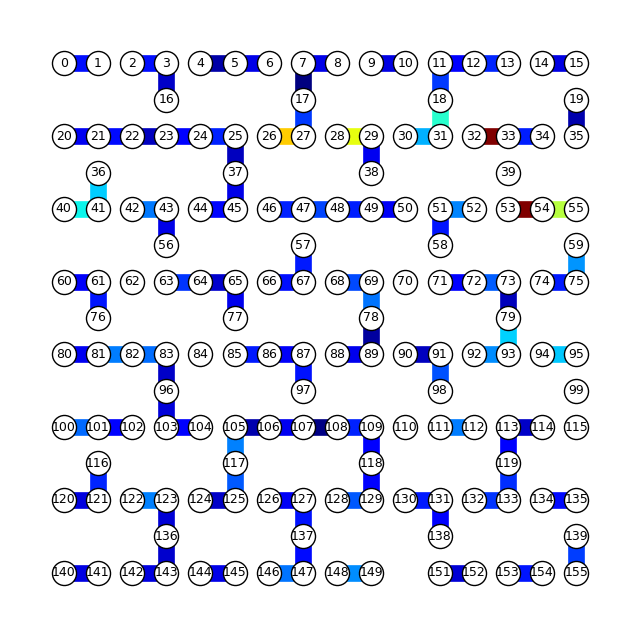

In [13]:
pos = [[i[1],-i[0]] for i in layout_fez.values()]
data = {layer: np.load(f"./Data/ibm_fez/shadows_{layer}.npy", allow_pickle=True).item() for layer in layers}
colors = plt.get_cmap("jet")
layer = 0
G = nx.Graph()
G.add_nodes_from(range(127))
prob_name = "Sab"
max_3q = max([data[layer]["postprocessing"][tuple(qubits)]["ZECS"][prob_name] for qubits in data[layer]["list_3q"]])
max_4q = max([data[layer]["postprocessing"][tuple(qubits)]["ZECS"][prob_name] for qubits in data[layer]["list_4q"]])
all_layers = data[layer]["layers"][0] + data[layer]["layers"][1] + data[layer]["layers"][2]
# color_dict = {0.1:cm_colors(0), 0.2:cm_colors(1), 0.3:cm_colors(2), 0.5:cm_colors(3), 1.0:cm_colors(4)}
edges_weight = []
for qubits in data[layer]["list_3q"]:
    Sab = data[layer]["postprocessing"][tuple(qubits)]["ZECS"]["Sab"]
    if (qubits[1:] in data[layer]["layers"][0] + data[layer]["layers"][1] + data[layer]["layers"][2]) or (qubits[1:][::-1] in data[layer]["layers"][0] + data[layer]["layers"][1] + data[layer]["layers"][2]):
        G.add_weighted_edges_from([[qubits[1],qubits[2],Sab/max_3q]])
    else:
        G.add_weighted_edges_from([[qubits[0],qubits[2],Sab/max_3q]]) 
for qubits in data[layer]["list_4q"]:
    Sab = data[layer]["postprocessing"][tuple(qubits)]["ZECS"]["Sab"]
    if [qubits[1],qubits[2]] in all_layers or [qubits[2],qubits[1]] in all_layers:
        G.add_weighted_edges_from([[qubits[1],qubits[2],Sab/max_4q]])
    elif [qubits[0],qubits[3]] in all_layers or [qubits[3],qubits[0]] in all_layers:
        G.add_weighted_edges_from([[qubits[0],qubits[3],Sab/max_4q]])
    elif [qubits[1],qubits[3]] in all_layers or [qubits[3],qubits[1]] in all_layers:
        G.add_weighted_edges_from([[qubits[1],qubits[3],Sab/max_4q]])
    elif [qubits[0],qubits[2]] in all_layers or [qubits[2],qubits[0]] in all_layers:
        G.add_weighted_edges_from([[qubits[2],qubits[0],Sab/max_4q]])
    else:
        print(qubits)
    # elif [qubits[0],qubits[2]]


weights = np.array([G[i][j]["weight"] for i, j in G.edges])
norm_weights = (weights - weights.min())/(weights.max() - weights.min())
edge_colors = [colors(w) for w in norm_weights]

fig, ax = plt.subplots(figsize=(8,8))
# plot_layout_background(ax, alpha=0.1)
nx.draw(G, pos=pos, ax=ax, font_size=9, edgecolors="black", width=12, edge_color=edge_colors, node_color="white",with_labels=True)

fig.savefig(f"./Figures/ibm_fez_{prop_name}_{layer}.pdf", bbox_inches="tight", transparent=True)

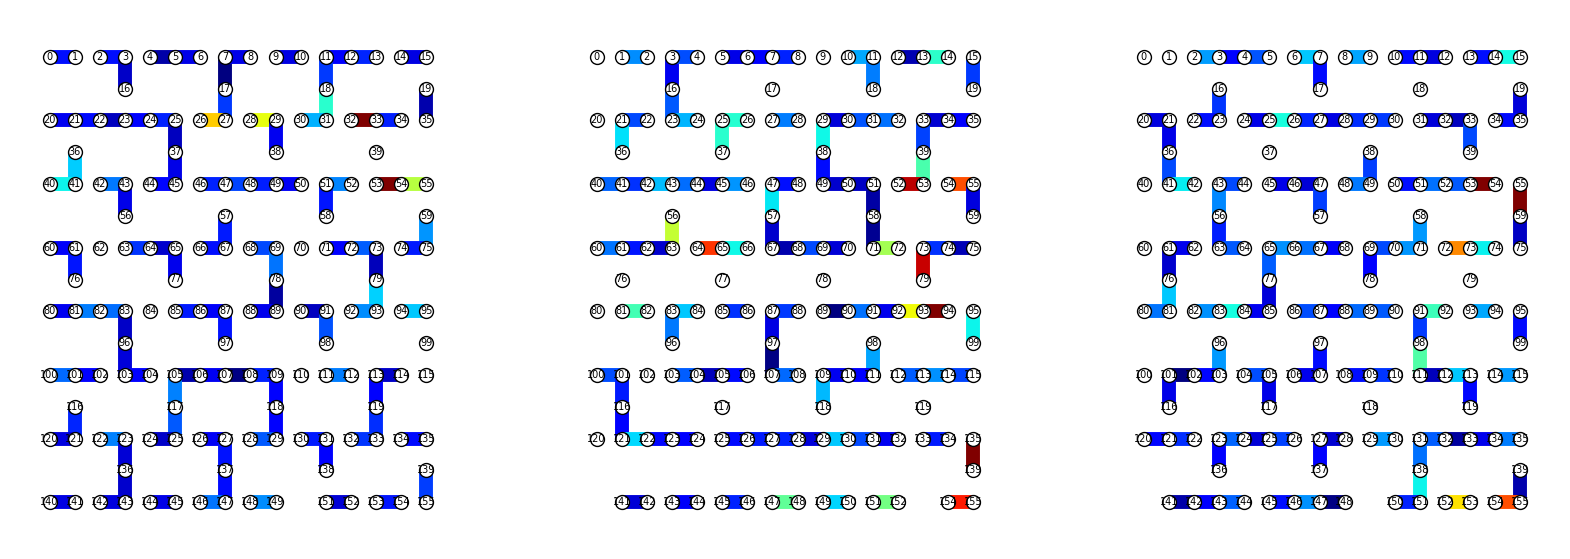

In [14]:
pos = [[i[1],-i[0]] for i in layout_fez.values()]
data = {layer: np.load(f"./Data/ibm_fez/shadows_{layer}.npy", allow_pickle=True).item() for layer in layers}
colors = plt.get_cmap("jet")
layers = [0,1,2]
fig, ax = plt.subplots(1, 3, figsize=(20,7))
for layer in layers:
    G = nx.Graph()
    G.add_nodes_from(range(127))
    prob_name = "Sab"
    max_3q = max([data[layer]["postprocessing"][tuple(qubits)]["ZECS"][prob_name] for qubits in data[layer]["list_3q"]])
    max_4q = max([data[layer]["postprocessing"][tuple(qubits)]["ZECS"][prob_name] for qubits in data[layer]["list_4q"]])
    all_layers = data[layer]["layers"][0] + data[layer]["layers"][1] + data[layer]["layers"][2]
    # color_dict = {0.1:cm_colors(0), 0.2:cm_colors(1), 0.3:cm_colors(2), 0.5:cm_colors(3), 1.0:cm_colors(4)}
    edges_weight = []
    for qubits in data[layer]["list_3q"]:
        Sab = data[layer]["postprocessing"][tuple(qubits)]["ZECS"]["Sab"]
        if (qubits[1:] in data[layer]["layers"][0] + data[layer]["layers"][1] + data[layer]["layers"][2]) or (qubits[1:][::-1] in data[layer]["layers"][0] + data[layer]["layers"][1] + data[layer]["layers"][2]):
            G.add_weighted_edges_from([[qubits[1],qubits[2],Sab/max_3q]])
        else:
            G.add_weighted_edges_from([[qubits[0],qubits[2],Sab/max_3q]]) 
    for qubits in data[layer]["list_4q"]:
        Sab = data[layer]["postprocessing"][tuple(qubits)]["ZECS"]["Sab"]
        if [qubits[1],qubits[2]] in all_layers or [qubits[2],qubits[1]] in all_layers:
            G.add_weighted_edges_from([[qubits[1],qubits[2],Sab/max_4q]])
        elif [qubits[0],qubits[3]] in all_layers or [qubits[3],qubits[0]] in all_layers:
            G.add_weighted_edges_from([[qubits[0],qubits[3],Sab/max_4q]])
        elif [qubits[1],qubits[3]] in all_layers or [qubits[1],qubits[3]] in all_layers:
            G.add_weighted_edges_from([[qubits[1],qubits[3],Sab/max_4q]])
        elif [qubits[0],qubits[2]] in all_layers or [qubits[2],qubits[0]] in all_layers:
            G.add_weighted_edges_from([[qubits[2],qubits[0],Sab/max_4q]])
        else:
            print(qubits)

    weights = np.array([G[i][j]["weight"] for i, j in G.edges])
    norm_weights = (weights - weights.min())/(weights.max() - weights.min())
    edge_colors = [colors(w) for w in norm_weights]

    nx.draw(G, pos=pos, ax=ax[layer], node_size=100, font_size=7, edgecolors="black", width=10, edge_color=edge_colors, node_color="white",with_labels=True)

fig.savefig(f"./Figures/ibm_fez_{prop_name}_layers.pdf", bbox_inches="tight", transparent=True)

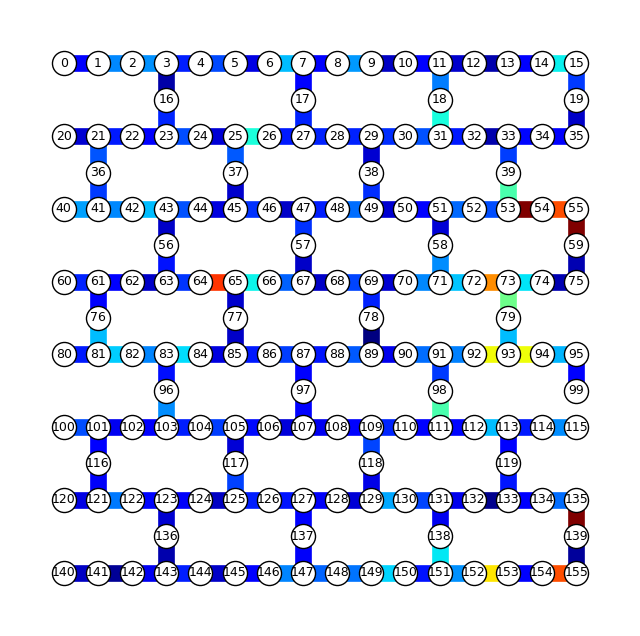

In [15]:
pos = [[i[1],-i[0]] for i in layout_fez.values()]
layers = [0,1,2]
data = {layer: np.load(f"./Data/ibm_fez/shadows_{layer}.npy", allow_pickle=True).item() for layer in layers}
colors = plt.get_cmap("jet")
layers = [0,1,2]
weights_mean = defaultdict(list)
prop_name = "Sab"
for layer in layers:
    max_3q = max([data[layer]["postprocessing"][tuple(qubits)]["ZECS"][prop_name] for qubits in data[layer]["list_3q"]])
    max_4q = max([data[layer]["postprocessing"][tuple(qubits)]["ZECS"][prop_name] for qubits in data[layer]["list_4q"]])
    all_layers = data[layer]["layers"][0] + data[layer]["layers"][1] + data[layer]["layers"][2]
    # color_dict = {0.1:cm_colors(0), 0.2:cm_colors(1), 0.3:cm_colors(2), 0.5:cm_colors(3), 1.0:cm_colors(4)}
    edges_weight = []
    for qubits in data[layer]["list_3q"]:
        Sab = data[layer]["postprocessing"][tuple(qubits)]["ZECS"]["Sab"]
        if (qubits[1:] in data[layer]["layers"][0] + data[layer]["layers"][1] + data[layer]["layers"][2]) or (qubits[1:][::-1] in data[layer]["layers"][0] + data[layer]["layers"][1] + data[layer]["layers"][2]):
            weights_mean[(qubits[1],qubits[2])].append(Sab/max_3q)
        else:
            weights_mean[(qubits[0],qubits[2])].append(Sab/max_3q)
    for qubits in data[layer]["list_4q"]:
        Sab = data[layer]["postprocessing"][tuple(qubits)]["ZECS"]["Sab"]
        if [qubits[1],qubits[2]] in all_layers or [qubits[2],qubits[1]] in all_layers:
            weights_mean[(qubits[1],qubits[2])].append(Sab/max_4q)
        elif [qubits[0],qubits[3]] in all_layers or [qubits[3],qubits[0]] in all_layers:
            weights_mean[(qubits[0],qubits[3])].append(Sab/max_4q)
        elif [qubits[1],qubits[3]] in all_layers or [qubits[3],qubits[1]] in all_layers:
            weights_mean[(qubits[1],qubits[3])].append(Sab/max_4q)
        elif [qubits[0],qubits[2]] in all_layers or [qubits[2],qubits[0]] in all_layers:
            weights_mean[(qubits[2],qubits[0])].append(Sab/max_4q)
        else:
            print(qubits)

    
G = nx.Graph()
G.add_nodes_from(range(156))
for qubits, weights in weights_mean.items():
    G.add_weighted_edges_from([[qubits[0],qubits[1],np.mean(weights)]])
weights = np.array([G[i][j]["weight"] for i, j in G.edges])
norm_weights = (weights - weights.min())/(weights.max() - weights.min())
edge_colors = [colors(w) for w in norm_weights]
fig, ax = plt.subplots(figsize=(8,8))
# plot_layout_background(ax, alpha=0.1)
nx.draw(G, pos=pos, ax=ax, font_size=9, edgecolors="black", width=12, edge_color=edge_colors, node_color="white",with_labels=True)
np.save("./Data/average_entropy_fez.npy", {"G":G})
fig.savefig(f"./Figures/ibm_fez_{prop_name}_layers_mean.pdf", bbox_inches="tight", transparent=True)

Entropy aware: entropy = 0.14244104004715322 (0.06170065090861164)
Fidelity aware: entropy = 0.18557937355568108 (0.07927522000182738)


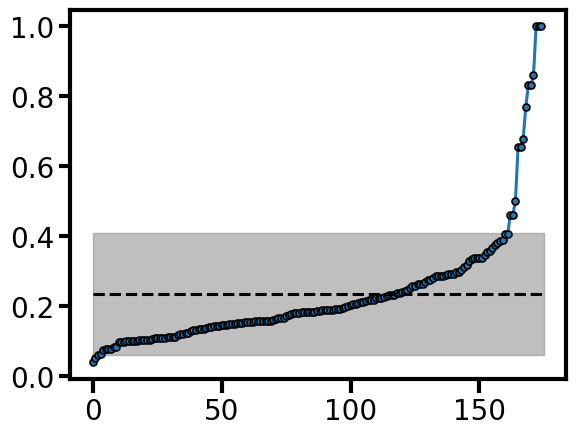

In [16]:
G_entropy = np.load("./Data/average_entropy_fez.npy", allow_pickle=True).item()["G"]
# qubits_line_entropy = [57,67,68,69,78,89,88,87,97,107,106,105,117,125,126,127,137,147,146,145,144,143,142,141,140]
qubits_line_entropy = [71, 70, 69, 78, 89, 88, 87, 97, 107, 106, 105, 117, 125, 124, 123, 136, 143, 142, 141, 140]
qubits_line_fidelity = [34,35,19,15,14,13,12,11,18,31,30,29,38,49,48,47,57,67,68,69,78,89,88,87,86,85,84,83,96,103,104,105,106,107,108,109,110,111,112,113,119,133,132,131,130,129,128,127,126,125,124,123,136,143,144,145,146,147,148,149]
edges_entropy = [[qubits_line_entropy[i],qubits_line_entropy[i+1]] for i in range(len(qubits_line_entropy)-1)]
edges_fidelity = [[qubits_line_fidelity[i],qubits_line_fidelity[i+1]] for i in range(len(qubits_line_fidelity)-1)]
fig, ax = plt.subplots()
Sab = np.array([G_entropy[i][j]["weight"] for i,j in G_entropy.edges])
edges = np.array([[i,j] for i,j in G_entropy.edges])
worst_edges = edges[Sab > Sab.mean() + Sab.std()]

ax.plot(sorted(Sab), marker="o", markeredgecolor="black")
ax.plot([0, len(G_entropy.edges)], 2*[Sab.mean()], linestyle="--", color="black")
ax.fill_between([0, len(G_entropy.edges)], 2*[Sab.mean()-Sab.std()], 2*[Sab.mean()+Sab.std()], color="grey", alpha=0.5)

print("Entropy aware: entropy =", np.mean([G_entropy[i][j]["weight"] for i,j in edges_entropy]),f'({np.std([G_entropy[i][j]["weight"] for i,j in edges_entropy])})')
print("Fidelity aware: entropy =", np.mean([G_entropy[i][j]["weight"] for i,j in edges_fidelity]),f'({np.std([G_entropy[i][j]["weight"] for i,j in edges_fidelity])})')



(11, 12)
(11, 18)
(12, 13)
(13, 14)
(14, 15)
(15, 19)
(18, 31)
(19, 35)
(29, 30)
(29, 38)
(30, 31)
(34, 35)
(38, 49)
(47, 48)
(47, 57)
(48, 49)
(57, 67)
(67, 68)
(68, 69)
(69, 78)
(78, 89)
(83, 84)
(83, 96)
(84, 85)
(85, 86)
(86, 87)
(87, 88)
(87, 97)
(88, 89)
(96, 103)
(97, 107)
(103, 104)
(104, 105)
(105, 106)
(105, 117)
(106, 107)
(107, 108)
(108, 109)
(109, 110)
(110, 111)
(111, 112)
(112, 113)
(113, 119)
(117, 125)
(119, 133)
(123, 124)
(123, 136)
(124, 125)
(125, 126)
(126, 127)
(127, 137)
(127, 128)
(128, 129)
(129, 130)
(130, 131)
(131, 132)
(132, 133)
(136, 143)
(137, 147)
(140, 141)
(141, 142)
(142, 143)
(143, 144)
(144, 145)
(145, 146)
(146, 147)
(147, 148)
(148, 149)


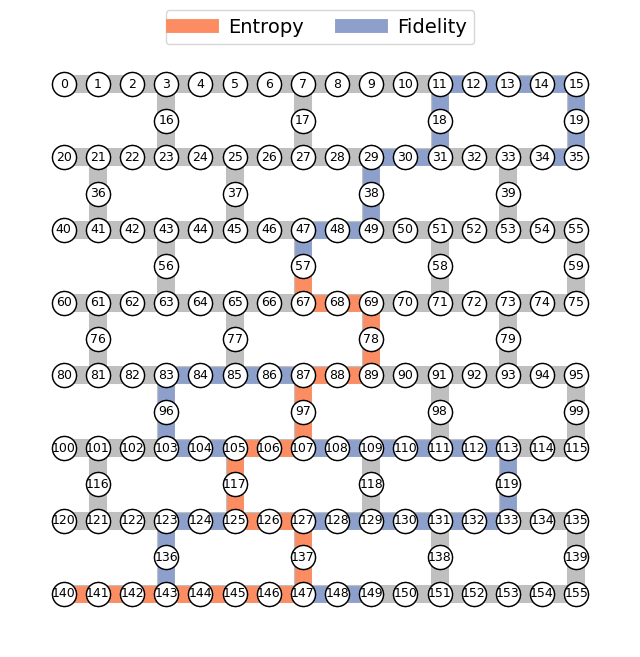

In [17]:
pos = [[i[1],-i[0]] for i in layout_fez.values()]
colors = plt.get_cmap("Set2")
nq = 20
G = nx.Graph()
G.add_nodes_from(range(156))
qubits_line_entropy = [57,67,68,69,78,89,88,87,97,107,106,105,117,125,126,127,137,147,146,145,144,143,142,141,140]
qubits_line_fidelity = [34,35,19,15,14,13,12,11,18,31,30,29,38,49,48,47,57,67,68,69,78,89,88,87,86,85,84,83,96,103,104,105,106,107,108,109,110,111,112,113,119,133,132,131,130,129,128,127,126,125,124,123,136,143,144,145,146,147,148,149]
edges_entropy = [[qubits_line_entropy[i],qubits_line_entropy[i+1]] for i in range(len(qubits_line_entropy)-1)]
edges_fidelity = [[qubits_line_fidelity[i],qubits_line_fidelity[i+1]] for i in range(len(qubits_line_fidelity)-1)]
G.add_edges_from(edges_entropy)
G.add_edges_from(edges_fidelity)

# color_dict = {0.1:cm_colors(0), 0.2:cm_colors(1), 0.3:cm_colors(2), 0.5:cm_colors(3), 1.0:cm_colors(4)}

# edge_colors = [(colors(1) if data[v] else "None") for v in G.edges]
edge_colors = []
for v in G.edges:
    print(v)
    if list(v) in edges_entropy or list(reversed(v)) in edges_entropy:
        edge_colors.append(colors(1))
    elif list(v) in edges_fidelity or list(reversed(v)) in edges_fidelity:
        edge_colors.append(colors(2))
    else:
        edge_colors.append("None")

fig, ax = plt.subplots(figsize=(8,8))
layers = np.load(f"./Data/ibm_fez/shadows_0.npy", allow_pickle=True).item()["layers"]
plot_layout_background(layout_fez, layers, ax, alpha=0.5)
nx.draw(G, pos=pos, ax=ax, font_size=9, edgecolors="black", width=12, edge_color=edge_colors, node_color="white",with_labels=True)
# for i, color in color_dict.items(): 
ax.plot([],[], linewidth= 10, color=colors(1), label="Entropy")
ax.plot([],[], linewidth= 10, color=colors(2), label="Fidelity")

ax.legend(loc="upper center", bbox_to_anchor=(0.5,1.05), ncols=5)
# fig.savefig(f"./Figures/HE/routing_{nq}.pdf", bbox_inches="tight", transparent=True)

# Entropy at each layer

In [18]:
backend_name = "ibm_fez"
layer = 0
results = np.load(f"./Data/{backend_name}/shadows_{layer}.npy", allow_pickle=True).item()
Sab = results["Sab"]

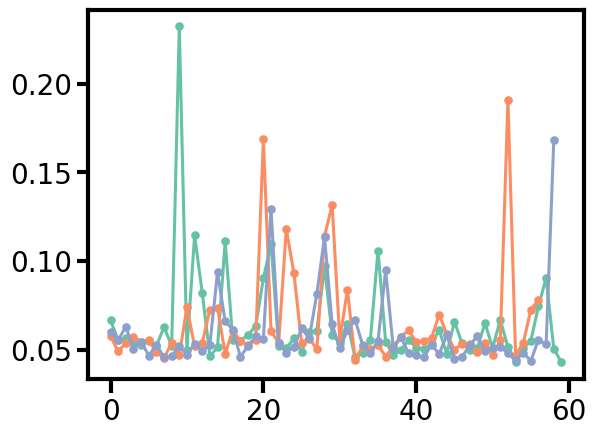

In [19]:
backend_name = "ibm_fez"
colors = plt.get_cmap("Set2")
fig, ax = plt.subplots()
qubit_dict = {}
s_dict = {}
n_edges = 10
for layer in range(3):
    results = np.load(f"./Data/{backend_name}/shadows_{layer}.npy", allow_pickle=True).item()
    Sab = results["Sab"][:len(results["layers"][layer]),:len(results["layers"][layer])]
    n_edges = np.sum(Sab.mean(axis=1) > 0.07)
    qubit_dict[layer] = np.array(results["layers"][layer])[np.argsort(Sab.mean(axis=1))[-n_edges:][::-1]]
    s_dict[layer] = np.sort(Sab.mean(axis=1))[-n_edges:][::-1]
    s = Sab[:len(results["layers"][layer])]
    ax.plot(s.mean(axis=1), marker="o", label=f"{layer}", color=colors(layer))
    # ax.hlines(np.median(s), 0, len(results["layers"][layer]), linestyles="--", color=colors(layer))

In [20]:
G_bad = nx.Graph()
for layer in range(3):  
    G_bad.add_weighted_edges_from([[qubit_dict[layer][i][0], qubit_dict[layer][i][1], s_dict[layer][i]] for i in range(len(qubit_dict[layer]))])
np.save(f"./Data/ibm_fez/G_bad.npy", {"G":G_bad})

# Average entropy

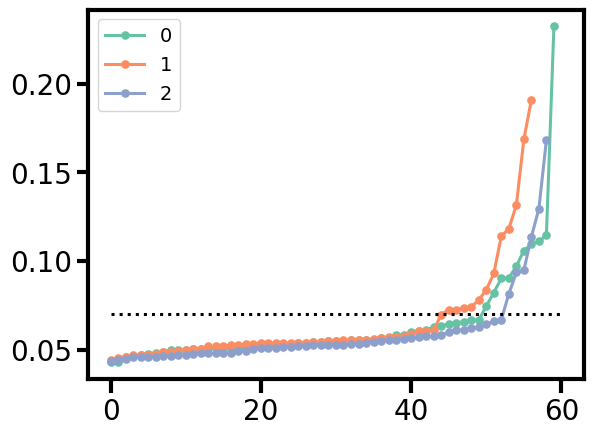

In [21]:
backend_name = "ibm_fez"
colors = plt.get_cmap("Set2")
fig, ax = plt.subplots()
qubit_dict_best = {}
s_dict_best = {}
for layer in range(3):
    results = np.load(f"./Data/{backend_name}/shadows_{layer}.npy", allow_pickle=True).item()
    Sab = results["Sab"][:len(results["layers"][layer]),:len(results["layers"][layer])]
    n_edges = np.sum(Sab.mean(axis=1) < 0.07)
    qubit_dict[layer] = np.array(results["layers"][layer])[np.argsort(Sab.mean(axis=1))[:n_edges]]
    s_dict[layer] = np.sort(Sab.mean(axis=1))[:n_edges]
    s = Sab[:len(results["layers"][layer])]
    ax.plot(np.sort(s.mean(axis=1)), marker="o", color=colors(layer), label=layer)
    # ax.vlines(45,0,0.15, color="black", linestyle="--")
    # ax.vlines(n_edges,0,0.15, color="black", linestyle=":")
ax.hlines(0.07,0,60, color="black", linestyle=":")
ax.legend()
fig.savefig(f"./Figures/ibm_fez_Sab.pdf", bbox_inches="tight", transparent=True)

In [22]:
G_good = nx.Graph()
for layer in range(3):  
    G_good.add_weighted_edges_from([[qubit_dict[layer][i][0], qubit_dict[layer][i][1], s_dict[layer][i]] for i in range(len(qubit_dict[layer]))])
np.save(f"./Data/ibm_fez/G_good.npy", {"G":G_good})

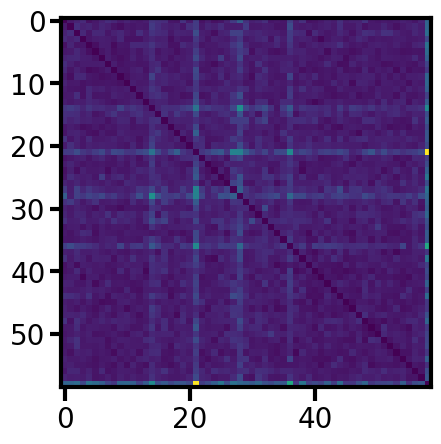

In [23]:
len_2q = len(results["layers"][layer])
plt.imshow(results["Sab"][:len_2q,:len_2q])

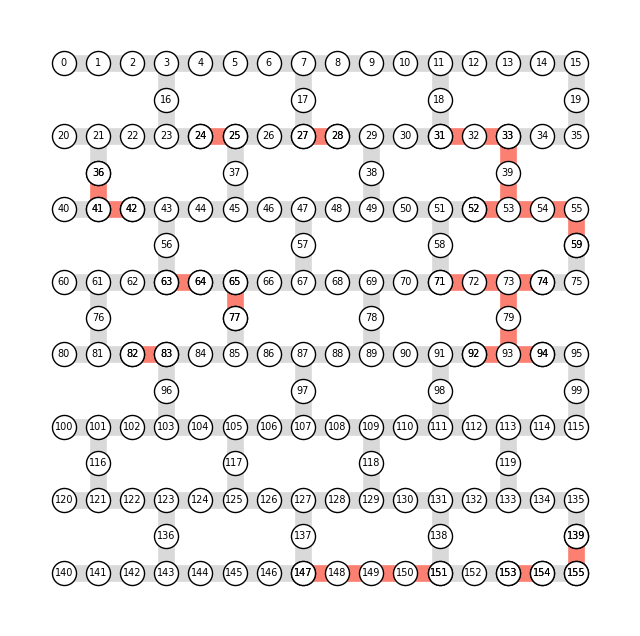

In [24]:
fig, ax = plt.subplots(figsize=(8,8))
pos = [[i[1],-i[0]] for i in layout_fez.values()]
G_good = np.load("./Data/ibm_fez/G_good.npy", allow_pickle=True).item()["G"]
G_bad = np.load("./Data/ibm_fez/G_bad.npy", allow_pickle=True).item()["G"]
colors = plt.get_cmap("Set3")
nx.draw(G_good, pos=pos, ax=ax, font_size=7, edgecolors="black", width=12, edge_color=colors(8), node_color="white",with_labels=True)
nx.draw(G_bad, pos=pos, ax=ax, font_size=7, edgecolors="black", width=12, edge_color=colors(3), node_color="white",with_labels=True)
fig.savefig(f"./Figures/ibm_fez_good_bad.pdf", bbox_inches="tight", transparent=True)

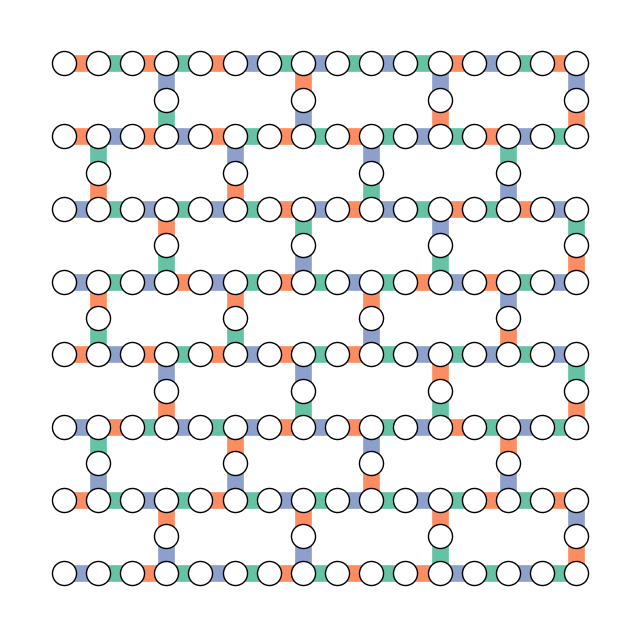

In [94]:
G = nx.Graph()
G.add_nodes_from(layout_fez.keys())
G.add_edges_from(layers[0]+ layers[1] + layers[2])
edge_color = [(colors(0) if list(ij) in layers[0] else (colors(1) if list(ij) in layers[1] else colors(2))) for ij in G.edges]
fig, ax = plt.subplots(figsize=(8,8))
nx.draw(G, pos=pos, ax=ax, font_size=9, edgecolors="black", width=12, edge_color=edge_color, node_color="white")
fig.savefig("./Figures/ZECS/ibm_fez_layers.pdf", bbox_inches="tight", transparent=True)

# Entropy

edge_max [27, 28]
edge_min [154, 155]
0.4462821628356396


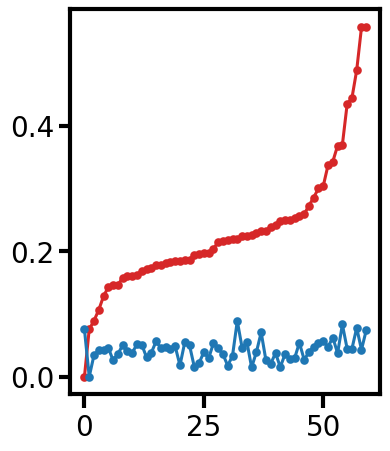

In [25]:
layer = 0
results = np.load(f"./Data/{backend_name}/shadows_{layer}.npy", allow_pickle=True).item()
Sab = results["Sab"][:len(results["layers"][layer]),:len(results["layers"][layer])]
s = Sab.mean(axis=1)
n_max = np.argmax(s)
n_min = np.argmin(s)
fig, ax = plt.subplots(figsize=(4,5))
arg_sort = np.argsort(Sab[n_max])
ax.plot(Sab[n_max][arg_sort], label="max", marker="o", color="tab:red")
ax.plot(Sab[n_min][arg_sort], label="min", marker="o", color="tab:blue")
edge_max = layers[layer][n_max]
edge_min = layers[layer][n_min]
print("edge_max", edge_max)
print("edge_min", edge_min)
F = results["postprocessing"][tuple(edge_max)]["ZECS"]["F"][-1]
print(F)
fig.savefig(f"./Figures/ibm_fez_Sab_max_min_{layer}.pdf", bbox_inches="tight", transparent=True)

# Fidelity

[27, 28] [154, 155]


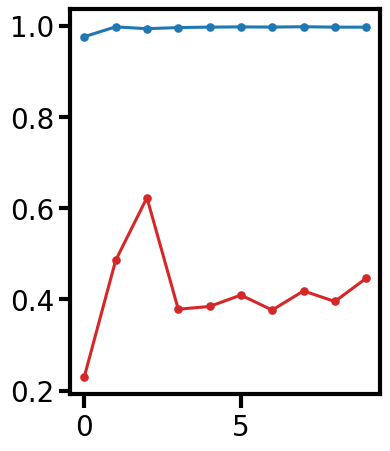

In [26]:
layer = 0
results = np.load(f"./Data/{backend_name}/shadows_{layer}.npy", allow_pickle=True).item()
Sab = results["Sab"][:len(results["layers"][layer]),:len(results["layers"][layer])]
s = Sab.mean(axis=1)
n_max = np.argmax(s)
n_min = np.argmin(s)
fig, ax = plt.subplots(figsize=(4,5))
arg_sort = np.argsort(Sab[n_max])

edge_max = layers[layer][n_max]
edge_min = layers[layer][n_min]
print(edge_max, edge_min)
F_max = results["postprocessing"][tuple(edge_max)]["ZECS"]["F"]
F_min = results["postprocessing"][tuple(edge_min)]["ZECS"]["F"]

ax.plot(F_max, label="max", marker="o", color="tab:red")
ax.plot(F_min, label="min", marker="o", color="tab:blue")
fig.savefig(f"./Figures/ibm_fez_F_max_min_{layer}.pdf", bbox_inches="tight", transparent=True)

[Text(0, 0, '00'), Text(1, 0, '01'), Text(2, 0, '10'), Text(3, 0, '11')]

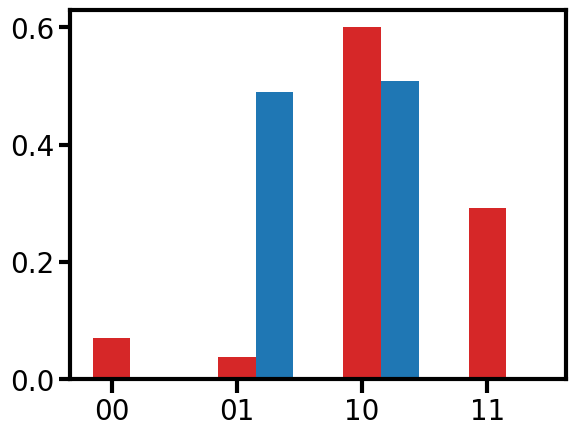

In [27]:
fig, ax = plt.subplots()
ax.bar(range(4),np.diag(results["postprocessing"][tuple(edge_max)]["ZECS"]["p"]).real, color="tab:red",width=0.3)
ax.bar(np.arange(4)+0.3, np.diag(results["postprocessing"][tuple(edge_min)]["ZECS"]["p"]).real, color="tab:blue",width=0.3)
ax.set_xticks(range(4))
ax.set_xticklabels(["00","01","10","11"])

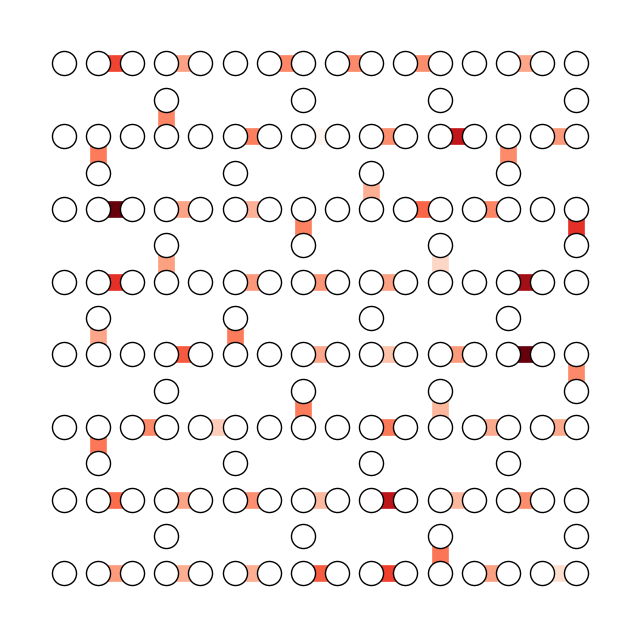

In [28]:
layer = 0
results = np.load(f"./Data/{backend_name}/shadows_{layer}.npy", allow_pickle=True).item()
Sab = results["Sab"][:len(results["layers"][layer]),:len(results["layers"][layer])]
s = Sab.mean(axis=1)
n_max = np.argmax(s)
S_used = Sab[n_max]/max(Sab[n_max])
colors = plt.get_cmap("Reds")
colors_1 = plt.get_cmap("Set2")
edge = layers[layer][n_max]
G = nx.Graph()
G.add_nodes_from(layout_fez.keys())
G.add_edges_from(layers[0]+ layers[1] + layers[2])
G.add_weighted_edges_from([[ij[0],ij[1],S_used[nn]] for nn, ij in enumerate(layers[layer])])
edge_color = [(colors(G[ij[0]][ij[1]]["weight"]) if list(ij) in layers[layer] else "white") for ij in G.edges]
fig, ax = plt.subplots(figsize=(8,8))
nx.draw(G, pos=pos, ax=ax, edgecolors="black", width=12, edge_color=edge_color, node_color="white")
fig.savefig(f"./Figures/ibm_fez_Sab_{layer}.pdf", bbox_inches="tight", transparent=True)

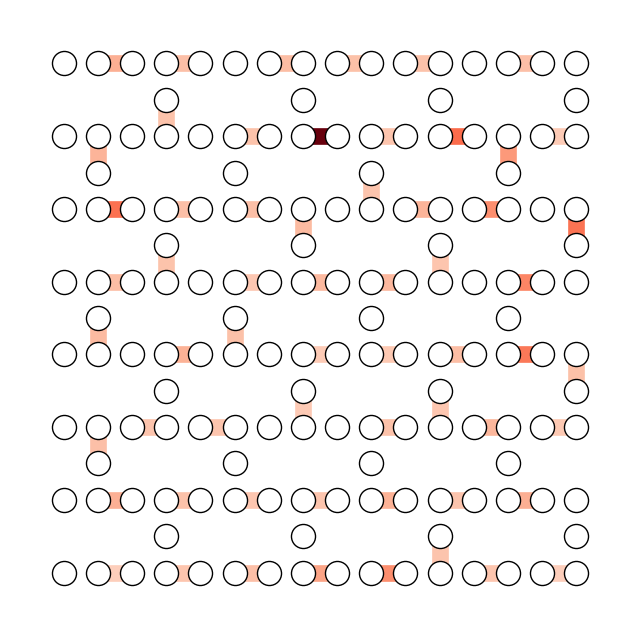

In [29]:
layer = 0
results = np.load(f"./Data/{backend_name}/shadows_{layer}.npy", allow_pickle=True).item()
Sab = results["Sab"][:len(results["layers"][layer]),:len(results["layers"][layer])]
s = Sab.mean(axis=1)
n_max = np.argmax(s)
S_used = s/max(s)
colors = plt.get_cmap("Reds")
colors_1 = plt.get_cmap("Set2")
edge = layers[layer][n_max]
G = nx.Graph()
G.add_nodes_from(layout_fez.keys())
G.add_edges_from(layers[0]+ layers[1] + layers[2])
G.add_weighted_edges_from([[ij[0],ij[1],S_used[nn]] for nn, ij in enumerate(layers[layer])])
edge_color = [(colors(G[ij[0]][ij[1]]["weight"]) if list(ij) in layers[layer] else "white") for ij in G.edges]
fig, ax = plt.subplots(figsize=(8,8))
nx.draw(G, pos=pos, ax=ax, edgecolors="black", width=12, edge_color=edge_color, node_color="white")
fig.savefig(f"./Figures/ibm_fez_Sab_{layer}.pdf", bbox_inches="tight", transparent=True)

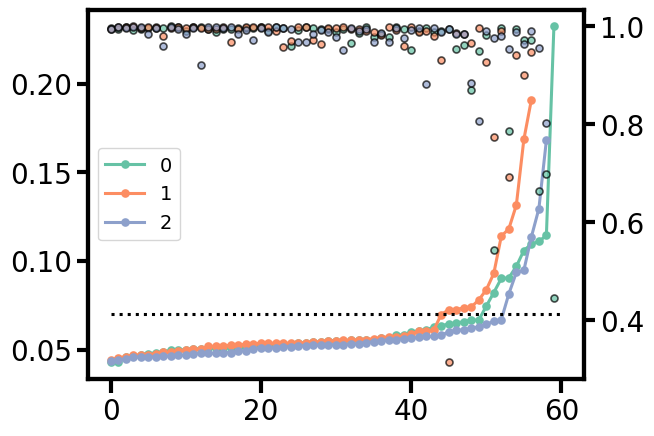

In [30]:
backend_name = "ibm_fez"
colors = plt.get_cmap("Set2")
fig, ax = plt.subplots()
qubit_dict_best = {}
s_dict_best = {}
ax2 = ax.twinx()
for layer in range(3):
    results = np.load(f"./Data/{backend_name}/shadows_{layer}.npy", allow_pickle=True).item()
    Sab = results["Sab"][:len(results["layers"][layer]),:len(results["layers"][layer])]
    n_edges = np.sum(Sab.mean(axis=1) < 0.07)
    qubit_dict[layer] = np.array(results["layers"][layer])[np.argsort(Sab.mean(axis=1))[:n_edges]]
    s_dict[layer] = np.sort(Sab.mean(axis=1))[:n_edges]
    s = Sab[:len(results["layers"][layer])]
    ax.plot(np.sort(s.mean(axis=1)), marker="o", color=colors(layer))
    
    F = [results["postprocessing"][tuple(layers[layer][i])]["ZECS"]["F"][-1] for i in np.argsort(Sab.mean(axis=1))] 
    ax2.plot(F, color=colors(layer), linewidth=0, marker="o", markeredgecolor="black", alpha=0.7)
    ax2.plot([], marker="o", color=colors(layer), label=layer)
    # ax.vlines(45,0,0.15, color="black", linestyle="--")
    # ax.vlines(n_edges,0,0.15, color="black", linestyle=":")
ax.hlines(0.07,0,60, color="black", linestyle=":")
ax2.legend(loc=6)
fig.savefig(f"./Figures/ibm_fez_Sab_F.pdf", bbox_inches="tight", transparent=True)